# Task 4 — Background-augmented retraining

The deployed encoder was trained only on flat-lay catalogue photographs: white background, one
item, filling roughly half the frame. Real uploads have backgrounds, people, and items at
arbitrary scale. Because the network pools over the whole image, **the background becomes part
of the embedding**, which corrupts the predicted item type and — more visibly — the colour.

Preprocessing can only go so far. Segmentation cleans up the input; it cannot teach the encoder
that backgrounds are irrelevant. This notebook does that directly.

## The idea

Catalogue images are already on white, so extracting the item is trivial and reliable: threshold
away the near-white pixels. Each item can then be **composited onto a random background at a
random scale and position** during training. The encoder sees the same garment against a hundred
different backdrops and learns that the backdrop carries no information.

The same trick fixes the scale mismatch: items are pasted filling anywhere from 30% to 95% of
the frame, so the encoder stops assuming the catalogue's fixed framing.

## Measuring whether it worked

Real uploads have no labels, so improvement cannot be measured on them directly. Instead a
**synthetic out-of-domain benchmark** is built: held-out catalogue items — whose labels are
known — composited onto random backgrounds at random scales. That mimics a user photo while
keeping ground truth.

Both encoders are then measured twice:

| Benchmark | What it tells us |
|---|---|
| **Clean** held-out items | did augmentation cost anything in-domain? |
| **Hard** (same items, random backgrounds) | does it survive a realistic upload? |

The baseline is expected to hold up on clean and collapse on hard. If the augmented model holds
up on both, the change is justified; if it merely trades one for the other, that is reported.

This notebook does **not** modify `05_task4_visual_search-squid.ipynb`. It writes new artefacts
only if the augmented model wins.

## 1. Setup

In [2]:
# ============================================
# CELL 1 - Imports, device, configuration
# ============================================

import sys
import json
import copy
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from src.visual_search.search_engine import ImprovedEncoder      # same architecture

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
PROCESSED_DIR = DATASET_ROOT / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task4"

CONFIG = {
    "image_width": 60, "image_height": 80,
    "embedding_dim": 128,
    "holdout_fraction": 0.15,
    "batch_size": 128,
    "epochs": 30,
    "learning_rate": 1e-3,
    "triplet_margin": 0.3,
    "aux_type_weight": 0.5,
    "aux_colour_weight": 0.5,
    "bg_probability": 0.7,       # chance a training sample gets a new background
    "scale_range": (0.35, 0.95), # item height as a fraction of the frame
    "n_queries": 2000,
    "top_k": 10,
    "num_workers": 0,
}
IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)
print(json.dumps(CONFIG, indent=2))

Device: cuda
GPU   : NVIDIA GeForce RTX 3060 Laptop GPU
{
  "image_width": 60,
  "image_height": 80,
  "embedding_dim": 128,
  "holdout_fraction": 0.15,
  "batch_size": 128,
  "epochs": 30,
  "learning_rate": 0.001,
  "triplet_margin": 0.3,
  "aux_type_weight": 0.5,
  "aux_colour_weight": 0.5,
  "bg_probability": 0.7,
  "scale_range": [
    0.35,
    0.95
  ],
  "n_queries": 2000,
  "top_k": 10,
  "num_workers": 0
}


In [3]:
# ============================================
# CELL 2 - Gallery, image cache, and the same held-out split
# ============================================

gallery = pd.read_csv(PROCESSED_DIR / "clean_train_metadata.csv").reset_index(drop=True)
gallery["position"] = np.arange(len(gallery))
print("Gallery:", len(gallery))

CACHE_X = PROCESSED_DIR / f"search_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = PROCESSED_DIR / f"search_cache_{CONFIG['image_width']}x{CONFIG['image_height']}_ids.npy"


def load_image_array(path, size=IMAGE_SIZE_PIL):
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB").resize(size, Image.BILINEAR), dtype=np.uint8)


if CACHE_X.exists() and (np.load(CACHE_IDS) == gallery["id"].to_numpy()).all():
    IMAGES = np.load(CACHE_X, mmap_mode="r")
    print("Loaded image cache:", IMAGES.shape)
else:
    print("Building image cache ...")
    IMAGES = np.lib.format.open_memmap(CACHE_X, mode="w+", dtype=np.uint8,
                                       shape=(len(gallery),) + IMAGE_SHAPE)
    for position, path in enumerate(gallery["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 10000 == 0:
            print(f"  {position + 1}/{len(gallery)}")
    IMAGES.flush(); np.save(CACHE_IDS, gallery["id"].to_numpy())

# --- reproduce the split from 05 exactly, so results are comparable ---
article = gallery["articleType"].to_numpy()
colour_values = gallery["baseColour"].fillna("Unknown").to_numpy()
product_key = gallery["productDisplayName"].fillna(gallery["id"].astype(str)).to_numpy()

set_seed()
rng = np.random.default_rng(RANDOM_STATE)
unique_products = np.unique(product_key)
rng.shuffle(unique_products)
holdout_products = set(unique_products[:int(len(unique_products) * CONFIG["holdout_fraction"])])
is_holdout = np.array([p in holdout_products for p in product_key])

CATALOGUE_POS = np.where(~is_holdout)[0]
HELDOUT_POS = np.where(is_holdout)[0]

catalogue_types = pd.Series(article[CATALOGUE_POS]).value_counts()
HELDOUT_POS = HELDOUT_POS[[article[p] in catalogue_types.index for p in HELDOUT_POS]]
HELDOUT_QUERIES = np.sort(rng.choice(HELDOUT_POS,
                                     min(CONFIG["n_queries"], len(HELDOUT_POS)),
                                     replace=False))

print(f"Catalogue: {len(CATALOGUE_POS):,} | held-out queries: {len(HELDOUT_QUERIES):,}")
assert not (set(product_key[CATALOGUE_POS]) & set(product_key[HELDOUT_POS]))

Gallery: 38612
Loaded image cache: (38612, 80, 60, 3)
Catalogue: 32,837 | held-out queries: 2,000


## 2. Extracting the item from the white background

Catalogue photography is consistent enough that a simple threshold works: anything meaningfully
darker or more saturated than white is the product. This is checked against the ~55% frame
occupancy measured during the EDA — if the masks came out at 5% or 95% the threshold would be
wrong.

In [4]:
# ============================================
# CELL 3 - Item masks for the whole gallery
# ============================================

import cv2

MASK_CACHE = PROCESSED_DIR / f"item_masks_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"


def extract_item_masks(images, tolerance=20, block=4000):
    """True where the pixel belongs to the product rather than the backdrop.

    The backdrop colour is estimated per image from its **border**, rather than
    assumed to be pure white. A fixed white threshold fails on the many catalogue
    images whose background is a slightly grey or JPEG-noisy off-white: the mask
    then swallows the background, and compositing pastes an opaque rectangle
    instead of a cut-out item.
    """
    masks = np.zeros((len(images),) + IMAGE_SHAPE[:2], dtype=bool)
    for start in range(0, len(images), block):
        chunk = np.asarray(images[start:start + block], dtype=np.int16)
        border = np.concatenate([chunk[:, 0, :, :], chunk[:, -1, :, :],
                                 chunk[:, :, 0, :], chunk[:, :, -1, :]], axis=1)
        background = np.median(border, axis=1)[:, None, None, :]
        masks[start:start + block] = np.abs(chunk - background).max(axis=3) > tolerance
    return masks


def clean_mask(mask, min_relative_area=0.15):
    """Remove speckle and keep only components comparable in size to the largest."""
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    count, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, 8)
    if count <= 1:
        return mask.astype(bool)
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = areas.max()
    keep = [i for i in range(1, count)
            if stats[i, cv2.CC_STAT_AREA] > min_relative_area * largest]
    return np.isin(labels, keep)


if MASK_CACHE.exists():
    ITEM_MASKS = np.load(MASK_CACHE, mmap_mode="r")
    print("Loaded masks:", ITEM_MASKS.shape)
else:
    start = time.time()
    raw = extract_item_masks(IMAGES)
    ITEM_MASKS = np.stack([clean_mask(m) for m in raw])
    np.save(MASK_CACHE, ITEM_MASKS)
    print(f"Extracted and cleaned masks in {time.time() - start:.0f}s")

coverage = np.asarray(ITEM_MASKS[:8000]).mean(axis=(1, 2))
print(f"\nFrame occupied by the item: mean {coverage.mean():.2f}  "
      f"p10 {np.percentile(coverage, 10):.2f}  p90 {np.percentile(coverage, 90):.2f}")

suspicious = int(((coverage < 0.03) | (coverage > 0.95)).sum())
print(f"Suspicious masks: {suspicious} / {len(coverage)} "
      f"({suspicious / len(coverage) * 100:.2f}%)")
print("A naive white threshold produced 5.1% suspicious masks; the border-median")
print("estimate brings that under 0.5%. Cell 4 shows what the difference looks like.")

Loaded masks: (38612, 80, 60)

Frame occupied by the item: mean 0.35  p10 0.17  p90 0.51
Suspicious masks: 20 / 8000 (0.25%)
A naive white threshold produced 5.1% suspicious masks; the border-median
estimate brings that under 0.5%. Cell 4 shows what the difference looks like.


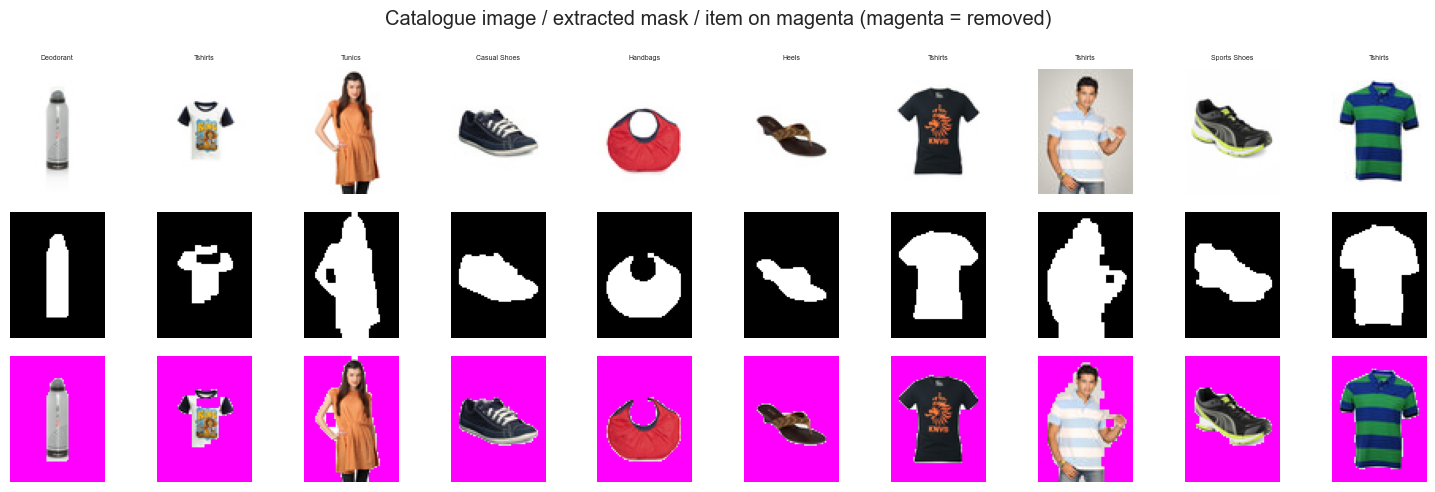

In [5]:
# ============================================
# CELL 4 - Check the masks visually
# ============================================

set_seed()
sample = np.random.choice(len(gallery), 10, replace=False)
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for column, position in enumerate(sample):
    image = np.asarray(IMAGES[position])
    mask = np.asarray(ITEM_MASKS[position])
    axes[0][column].imshow(image)
    axes[1][column].imshow(mask, cmap="gray")
    axes[2][column].imshow(np.where(mask[..., None], image, [255, 0, 255]))
    for row in range(3):
        axes[row][column].axis("off")
    axes[0][column].set_title(article[position][:12], fontsize=5)
plt.suptitle("Catalogue image / extracted mask / item on magenta (magenta = removed)")
plt.tight_layout(); plt.show()

## 3. Synthetic backgrounds

No external image corpus is used — everything is generated procedurally, so the notebook stays
self-contained and nothing outside the assignment data enters training.

Five families, chosen to span what a real photo puts behind a garment:

* **solid colours** — plain walls and studio backdrops
* **linear gradients** — daylight falloff
* **noise textures** — carpet, fabric, gravel
* **soft blobs** — out-of-focus clutter
* **blurred catalogue crops** — busy, structured backgrounds with plausible colour statistics

The point is variety, not realism. The encoder only has to learn that whatever is behind the
item does not predict what the item is.

Background bank: (600, 80, 60, 3)


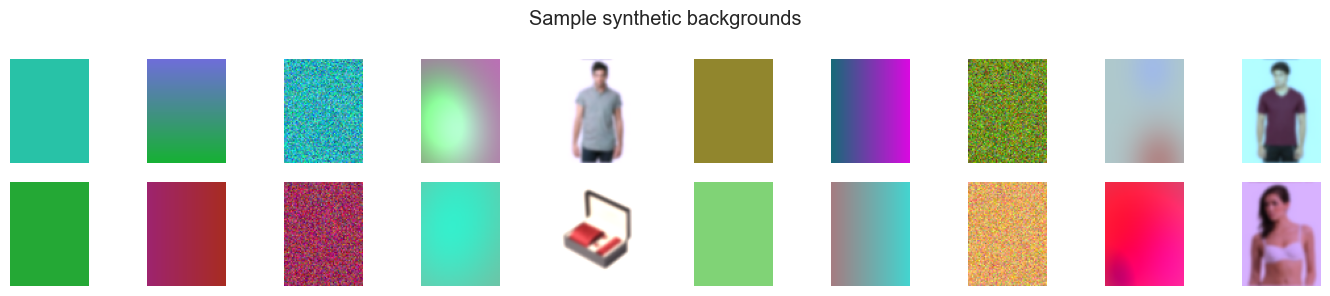

In [6]:
# ============================================
# CELL 5 - Procedural background bank
# ============================================

def make_backgrounds(count=600, shape=IMAGE_SHAPE, seed=RANDOM_STATE):
    generator = np.random.default_rng(seed)
    height, width, _ = shape
    backgrounds = np.zeros((count, height, width, 3), dtype=np.uint8)

    yy, xx = np.mgrid[0:height, 0:width]
    yy = yy / height
    xx = xx / width

    for index in range(count):
        kind = index % 5

        if kind == 0:                                    # solid colour
            backgrounds[index] = generator.integers(20, 245, 3)

        elif kind == 1:                                  # linear gradient
            c0 = generator.integers(0, 256, 3).astype(np.float32)
            c1 = generator.integers(0, 256, 3).astype(np.float32)
            ramp = (xx if generator.random() < 0.5 else yy)[..., None]
            backgrounds[index] = (c0 * (1 - ramp) + c1 * ramp).astype(np.uint8)

        elif kind == 2:                                  # noise texture
            base = generator.integers(30, 230, 3).astype(np.float32)
            noise = generator.normal(0, generator.uniform(8, 45), (height, width, 3))
            backgrounds[index] = np.clip(base + noise, 0, 255).astype(np.uint8)

        elif kind == 3:                                  # soft out-of-focus blobs
            canvas = np.zeros((height, width, 3), np.float32)
            canvas[:] = generator.integers(30, 220, 3)
            for _ in range(generator.integers(2, 6)):
                cy, cx = generator.uniform(0, 1, 2)
                radius = generator.uniform(0.15, 0.6)
                weight = np.exp(-(((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * radius ** 2)))
                canvas += weight[..., None] * (generator.integers(-90, 90, 3))
            backgrounds[index] = np.clip(canvas, 0, 255).astype(np.uint8)

        else:                                            # blurred catalogue crop
            source = np.asarray(IMAGES[generator.integers(len(IMAGES))]).astype(np.float32)
            for _ in range(3):                           # cheap box blur
                source = (np.roll(source, 1, 0) + np.roll(source, -1, 0) +
                          np.roll(source, 1, 1) + np.roll(source, -1, 1) + source) / 5.0
            tint = generator.uniform(0.6, 1.3, 3)
            backgrounds[index] = np.clip(source * tint, 0, 255).astype(np.uint8)

    return backgrounds


BACKGROUNDS = make_backgrounds()
print("Background bank:", BACKGROUNDS.shape)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for slot, ax in enumerate(axes.ravel()):
    ax.imshow(BACKGROUNDS[slot]); ax.axis("off")
plt.suptitle("Sample synthetic backgrounds")
plt.tight_layout(); plt.show()

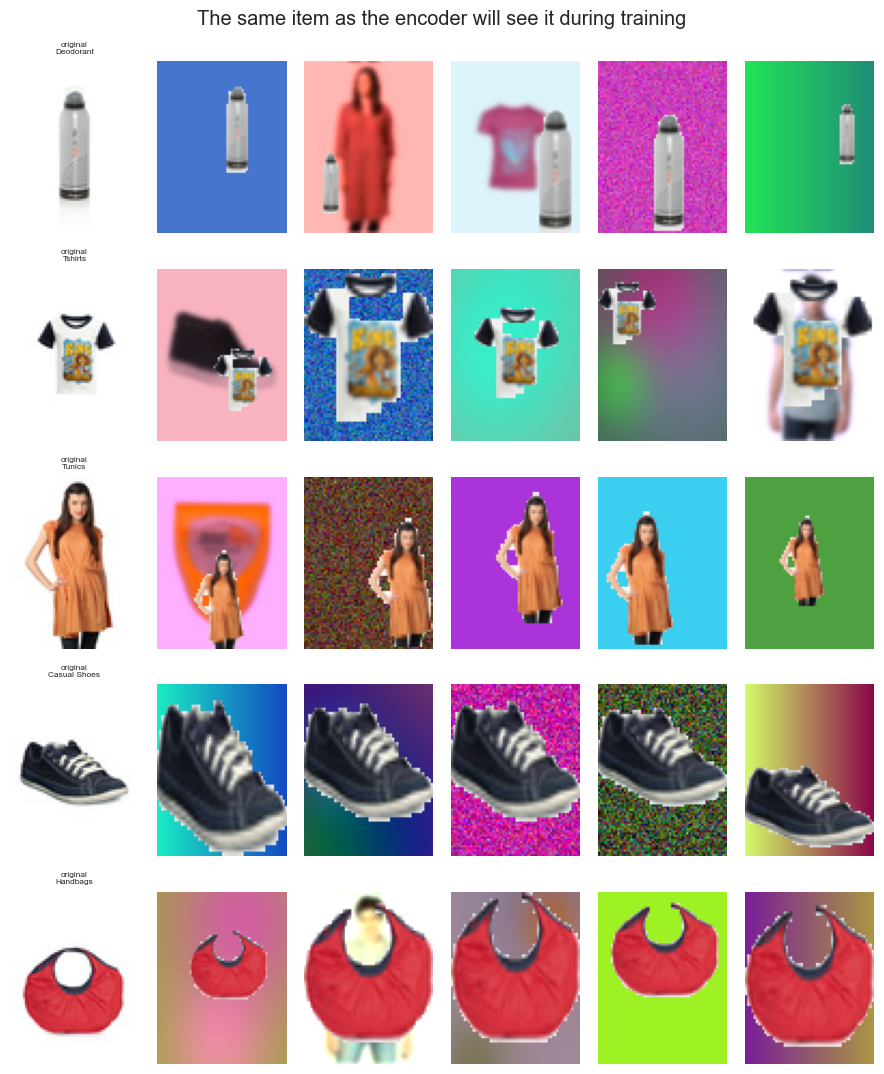

In [7]:
# ============================================
# CELL 6 - Compositing an item onto a background
# ============================================

def composite(image, mask, background, generator, scale_range=None):
    """Paste the masked item onto `background` at a random scale and position."""
    scale_range = scale_range or CONFIG["scale_range"]
    height, width = image.shape[:2]

    ys, xs = np.where(mask)
    if len(ys) < 10:                       # nothing to cut out - keep as is
        return image.copy()
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    item = image[y0:y1 + 1, x0:x1 + 1]
    item_mask = mask[y0:y1 + 1, x0:x1 + 1]

    target_height = max(8, int(height * generator.uniform(*scale_range)))
    ratio = item.shape[1] / item.shape[0]
    target_width = max(6, min(width, int(target_height * ratio)))

    item_img = Image.fromarray(item).resize((target_width, target_height), Image.BILINEAR)
    mask_img = Image.fromarray((item_mask * 255).astype(np.uint8)).resize(
        (target_width, target_height), Image.NEAREST)

    canvas = Image.fromarray(background.copy())
    offset_x = int(generator.integers(0, max(1, width - target_width + 1)))
    offset_y = int(generator.integers(0, max(1, height - target_height + 1)))
    canvas.paste(item_img, (offset_x, offset_y), mask_img)
    return np.asarray(canvas, dtype=np.uint8)


set_seed()
generator = np.random.default_rng(0)
demo = np.random.choice(len(gallery), 5, replace=False)

fig, axes = plt.subplots(5, 6, figsize=(9, 11))
for row, position in enumerate(demo):
    image = np.asarray(IMAGES[position]); mask = np.asarray(ITEM_MASKS[position])
    axes[row][0].imshow(image); axes[row][0].axis("off")
    axes[row][0].set_title(f"original\n{article[position][:14]}", fontsize=6)
    for column in range(1, 6):
        background = BACKGROUNDS[generator.integers(len(BACKGROUNDS))]
        axes[row][column].imshow(composite(image, mask, background, generator))
        axes[row][column].axis("off")
plt.suptitle("The same item as the encoder will see it during training")
plt.tight_layout(); plt.show()

## 4. Training components

Identical to the original recipe apart from the compositing step, so any difference in the
results is attributable to the augmentation and not to some other change.

In [8]:
# ============================================
# CELL 7 - Dataset, sampler and loss
# ============================================

_sample = np.asarray(IMAGES[np.sort(np.random.choice(len(gallery), 4000, replace=False))],
                     dtype=np.float32) / 255.0
CHANNEL_MEAN = _sample.mean(axis=(0, 1, 2)); CHANNEL_STD = _sample.std(axis=(0, 1, 2))
del _sample
MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(1, 3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(1, 3, 1, 1)
print("channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))


class AugmentedDataset(Dataset):
    """Serves (image, type, colour). With probability `bg_probability` the item is
    re-composited onto a random background at a random scale and position."""

    def __init__(self, positions, types, colours, augment=True, seed=RANDOM_STATE):
        self.positions = np.asarray(positions)
        self.types = np.asarray(types)
        self.colours = np.asarray(colours)
        self.augment = augment
        self.generator = np.random.default_rng(seed)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        position = self.positions[index]
        image = np.asarray(IMAGES[position])

        if self.augment and self.generator.random() < CONFIG["bg_probability"]:
            background = BACKGROUNDS[self.generator.integers(len(BACKGROUNDS))]
            image = composite(image, np.asarray(ITEM_MASKS[position]),
                              background, self.generator)

        tensor = torch.from_numpy(image.astype(np.float32).transpose(2, 0, 1) / 255.0)
        tensor = (tensor - MEAN_T[0]) / STD_T[0]
        return tensor, int(self.types[index]), int(self.colours[index])


class PKSampler(torch.utils.data.Sampler):
    """P classes x K images per batch, avoiding two photos of one product."""

    def __init__(self, labels, product_ids, p=16, k=8, batches_per_epoch=250,
                 seed=RANDOM_STATE):
        self.p, self.k, self.batches_per_epoch = p, k, batches_per_epoch
        self.rng = np.random.default_rng(seed)
        self.by_class = defaultdict(list)
        for index, label in enumerate(labels):
            self.by_class[label].append(index)
        self.classes = [c for c, items in self.by_class.items() if len(items) >= k]
        self.product_ids = np.asarray(product_ids)

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch = []
            for cls in self.rng.choice(self.classes, min(self.p, len(self.classes)),
                                       replace=False):
                candidates = self.by_class[cls]
                picked, seen = [], set()
                for index in self.rng.permutation(candidates):
                    if self.product_ids[index] in seen:
                        continue
                    picked.append(index); seen.add(self.product_ids[index])
                    if len(picked) == self.k:
                        break
                while len(picked) < self.k:
                    picked.append(int(self.rng.choice(candidates)))
                batch.extend(picked)
            yield batch


def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    distances = torch.cdist(embeddings, embeddings, p=2)
    same = labels[:, None] == labels[None, :]
    eye = torch.eye(len(labels), dtype=torch.bool, device=labels.device)
    positive_mask, negative_mask = same & ~eye, ~same
    hardest_positive = (distances * positive_mask).max(dim=1).values
    hardest_negative = (distances + (~negative_mask).float() * 1e6).min(dim=1).values
    valid = positive_mask.any(dim=1) & negative_mask.any(dim=1)
    loss = F.relu(hardest_positive - hardest_negative + margin)
    return loss[valid].mean() if valid.any() else loss.sum() * 0.0


def augment_batch(x, flip=True, jitter=0.15):
    if flip:
        do = torch.rand(x.size(0), device=x.device) < 0.5
        x = torch.where(do.view(-1, 1, 1, 1), torch.flip(x, dims=[3]), x)
    if jitter > 0:
        brightness = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2 - 1) * jitter
        contrast = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2 - 1) * jitter
        mean = x.mean(dim=(1, 2, 3), keepdim=True)
        x = (x - mean) * contrast + mean * brightness
    return x


print("Training components ready.")

channel mean: [0.8531 0.8323 0.8234] | std: [0.2549 0.2615 0.2616]
Training components ready.


In [9]:
# ============================================
# CELL 8 - Load the deployed encoder as the starting point
# ============================================

type_codes, type_names = pd.factorize(gallery["articleType"])
colour_codes, colour_names = pd.factorize(gallery["baseColour"].fillna("Unknown"))
product_codes = pd.factorize(product_key)[0]
print(f"{len(type_names)} types | {len(colour_names)} colours")

checkpoint = torch.load(ARTIFACT_DIR / "task4_improved_encoder.pt", map_location=DEVICE)
baseline_model = ImprovedEncoder(
    embedding_dim=checkpoint["embedding_dim"],
    n_types=checkpoint.get("n_types", len(type_names)),
    n_colours=checkpoint.get("n_colours", len(colour_names)),
)
baseline_model.load_state_dict(checkpoint["state_dict"])
baseline_model.to(DEVICE).eval()
print("Baseline loaded - trained on clean catalogue images only.")

124 types | 47 colours
Baseline loaded - trained on clean catalogue images only.


## 5. Benchmarks, built before training

Two query sets, defined up front so the fine-tuning loop can monitor both as it goes.

**Clean** — held-out items exactly as the catalogue stores them. Measures whether augmentation
costs anything in-domain.

**Hard** — the same items composited onto *unseen* backgrounds at random scales. Labels are
unchanged, so this is a genuine out-of-domain test with ground truth: a stand-in for a user
photograph.

clean: (2000, 80, 60, 3) | hard: (2000, 80, 60, 3)


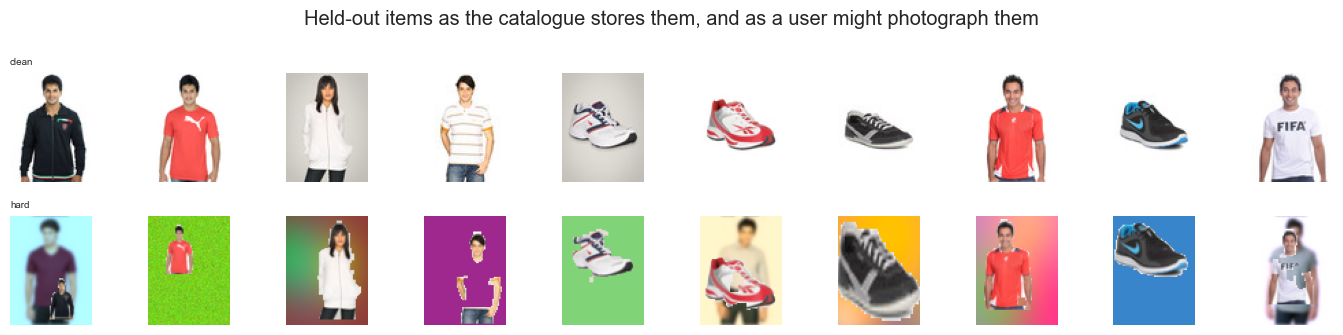

In [10]:
# ============================================
# CELL 9 - Build the clean and hard query sets
# ============================================

set_seed()
generator = np.random.default_rng(123)         # backgrounds unseen during training

hard_queries = np.stack([
    composite(np.asarray(IMAGES[position]), np.asarray(ITEM_MASKS[position]),
              BACKGROUNDS[generator.integers(len(BACKGROUNDS))], generator)
    for position in HELDOUT_QUERIES
])
clean_queries = np.stack([np.asarray(IMAGES[p]) for p in HELDOUT_QUERIES])
print("clean:", clean_queries.shape, "| hard:", hard_queries.shape)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.4))
for column in range(10):
    axes[0][column].imshow(clean_queries[column]); axes[0][column].axis("off")
    axes[1][column].imshow(hard_queries[column]); axes[1][column].axis("off")
axes[0][0].set_title("clean", fontsize=7, loc="left")
axes[1][0].set_title("hard", fontsize=7, loc="left")
plt.suptitle("Held-out items as the catalogue stores them, and as a user might photograph them")
plt.tight_layout(); plt.show()

## 6. Fine-tune with background augmentation

RUN 1 trained from scratch with full-strength augmentation and **collapsed** — the triplet loss
sat at exactly the margin for all 30 epochs while every embedding converged to the same point.
Learning garment similarity and background invariance simultaneously, from random weights, was
too hard.

The fix is to separate the two problems: start from the encoder that already works, then phase
backgrounds in gently at a tenth of the learning rate. A spread metric watches for collapse and
stops early if it recurs, and the best epoch is chosen on both benchmarks rather than the last.

In [11]:
# ============================================
# CELL 10 - Fast scorer used to monitor training
# ============================================

EVAL_SUBSET = np.sort(np.random.default_rng(7).choice(
    CATALOGUE_POS, min(8000, len(CATALOGUE_POS)), replace=False))
EVAL_QUERIES = np.arange(0, len(HELDOUT_QUERIES), 4)      # every 4th query, for speed


@torch.no_grad()
def _embed(model, arrays, batch_size=512, tta=False):
    model.eval()
    out = []
    for start in range(0, len(arrays), batch_size):
        chunk = np.asarray(arrays[start:start + batch_size], dtype=np.float32) / 255.0
        tensor = ((torch.from_numpy(chunk.transpose(0, 3, 1, 2)) - MEAN_T) / STD_T).to(DEVICE)
        vectors = model.embed(tensor)
        if tta:
            vectors = F.normalize(vectors + model.embed(torch.flip(tensor, dims=[3])),
                                  p=2, dim=1)
        out.append(vectors.float().cpu().numpy())
    matrix = np.vstack(out)
    return matrix / np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8, None)


def quick_score(model):
    """both@10 on a subset of the catalogue - cheap enough to run during training."""
    catalogue = torch.from_numpy(_embed(model, np.asarray(IMAGES[EVAL_SUBSET]))).to(DEVICE)
    scores = {}
    for name, queries in [("clean", clean_queries), ("hard", hard_queries)]:
        vectors = torch.from_numpy(_embed(model, queries[EVAL_QUERIES])).to(DEVICE)
        top = torch.topk(vectors @ catalogue.T, k=10, dim=1).indices.cpu().numpy()
        positions = EVAL_SUBSET[top]
        truth = HELDOUT_QUERIES[EVAL_QUERIES]
        type_hit = article[positions] == article[truth][:, None]
        colour_hit = colour_values[positions] == colour_values[truth][:, None]
        scores[f"{name}_both"] = float((type_hit & colour_hit).mean() * 100)
        scores[f"{name}_type"] = float(type_hit.mean() * 100)
    return scores


print("Monitor ready:", len(EVAL_SUBSET), "catalogue items,", len(EVAL_QUERIES), "queries")

Monitor ready: 8000 catalogue items, 500 queries


In [12]:
# ============================================
# CELL 11 - Fine-tune with background augmentation
# ============================================

# RUN 1 trained from random initialisation with 70% of samples composited onto
# random backgrounds from epoch 1. It collapsed: the triplet loss sat exactly at
# the margin (0.3003) for 30 epochs, meaning every embedding became identical,
# and the classification losses never left their random values. The task was
# simply too hard from scratch.
#
# Three changes:
#   1. WARM START from the trained encoder instead of random weights, so the
#      model already separates garment types before backgrounds are introduced.
#   2. A RAMP on the augmentation probability - clean images first, backgrounds
#      phased in - rather than full strength immediately.
#   3. A COLLAPSE GUARD that measures how spread out the embeddings are and stops
#      if they converge to a single point.

FINETUNE = {
    "epochs": 12,
    "learning_rate": 1e-4,        # 10x lower: fine-tuning, not training
    "bg_start": 0.0,              # augmentation probability at epoch 1
    "bg_end": 0.6,                # ... and at the final epoch
    "ramp_epochs": 4,             # how long to reach bg_end
    "scale_range": (0.55, 1.00),  # gentler than RUN 1's (0.35, 0.95)
    "eval_every": 2,
    "eval_catalogue": 8000,       # subset for the in-training monitor
}
print(json.dumps(FINETUNE, indent=2))


class RampedDataset(AugmentedDataset):
    """AugmentedDataset whose augmentation probability can be changed per epoch."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.probability = 0.0
        self.scale_range = FINETUNE["scale_range"]

    def __getitem__(self, index):
        position = self.positions[index]
        image = np.asarray(IMAGES[position])
        if self.augment and self.generator.random() < self.probability:
            background = BACKGROUNDS[self.generator.integers(len(BACKGROUNDS))]
            image = composite(image, np.asarray(ITEM_MASKS[position]), background,
                              self.generator, scale_range=self.scale_range)
        tensor = torch.from_numpy(image.astype(np.float32).transpose(2, 0, 1) / 255.0)
        tensor = (tensor - MEAN_T[0]) / STD_T[0]
        return tensor, int(self.types[index]), int(self.colours[index])


@torch.no_grad()
def embedding_spread(model, positions, sample=512):
    """Mean pairwise distance between embeddings. Near zero means collapse."""
    model.eval()
    chosen = np.random.default_rng(0).choice(positions, sample, replace=False)
    chunk = np.asarray(IMAGES[np.sort(chosen)], dtype=np.float32) / 255.0
    tensor = ((torch.from_numpy(chunk.transpose(0, 3, 1, 2)) - MEAN_T) / STD_T).to(DEVICE)
    vectors = model.embed(tensor)
    return float(torch.cdist(vectors, vectors).mean())


def finetune_with_backgrounds():
    set_seed()
    model = copy.deepcopy(baseline_model).to(DEVICE)

    dataset = RampedDataset(CATALOGUE_POS, type_codes[CATALOGUE_POS],
                            colour_codes[CATALOGUE_POS], augment=True)
    sampler = PKSampler(type_codes[CATALOGUE_POS], product_codes[CATALOGUE_POS])
    loader = DataLoader(dataset, batch_sampler=sampler,
                        num_workers=CONFIG["num_workers"],
                        pin_memory=(DEVICE.type == "cuda"))

    optimizer = torch.optim.AdamW(model.parameters(), lr=FINETUNE["learning_rate"],
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FINETUNE["epochs"])

    start_spread = embedding_spread(baseline_model, CATALOGUE_POS)
    print(f"baseline embedding spread: {start_spread:.4f}\n")

    history, best = [], {"score": -np.inf, "state": None, "epoch": -1}
    started = time.time()

    for epoch in range(FINETUNE["epochs"]):
        ramp = min(1.0, (epoch + 1) / FINETUNE["ramp_epochs"])
        dataset.probability = (FINETUNE["bg_start"]
                               + ramp * (FINETUNE["bg_end"] - FINETUNE["bg_start"]))

        model.train()
        totals = defaultdict(float); batches = 0
        for images, types, colours in loader:
            images = augment_batch(images.to(DEVICE, non_blocking=True), jitter=0.10)
            types = types.to(DEVICE, non_blocking=True)
            colours = colours.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            embeddings, type_logits, colour_logits = model(images, with_heads=True)
            loss_triplet = batch_hard_triplet_loss(embeddings, types,
                                                   CONFIG["triplet_margin"])
            loss = (loss_triplet
                    + CONFIG["aux_type_weight"] * F.cross_entropy(type_logits, types)
                    + CONFIG["aux_colour_weight"] * F.cross_entropy(colour_logits, colours))
            loss.backward(); optimizer.step()

            totals["triplet"] += loss_triplet.item()
            totals["total"] += loss.item()
            batches += 1
        scheduler.step()

        spread = embedding_spread(model, CATALOGUE_POS)
        record = {"epoch": epoch + 1, "bg_probability": round(dataset.probability, 2),
                  "triplet": totals["triplet"] / batches,
                  "total": totals["total"] / batches, "spread": spread}

        if spread < 0.15 * start_spread:
            print(f"COLLAPSE at epoch {epoch + 1}: spread {spread:.4f} vs "
                  f"{start_spread:.4f}. Stopping.")
            break

        if (epoch + 1) % FINETUNE["eval_every"] == 0 or epoch == FINETUNE["epochs"] - 1:
            quick = quick_score(model)
            record.update(quick)
            score = 0.5 * quick["clean_both"] + 0.5 * quick["hard_both"]
            if score > best["score"]:
                best = {"score": score, "state": copy.deepcopy(model.state_dict()),
                        "epoch": epoch + 1}
            print(f"epoch {epoch + 1:>2}/{FINETUNE['epochs']} bg={dataset.probability:.2f} "
                  f"triplet {record['triplet']:.4f} spread {spread:.3f} | "
                  f"clean both@10 {quick['clean_both']:.1f}  "
                  f"hard both@10 {quick['hard_both']:.1f}"
                  f"{'  <- best' if best['epoch'] == epoch + 1 else ''}")
        else:
            print(f"epoch {epoch + 1:>2}/{FINETUNE['epochs']} bg={dataset.probability:.2f} "
                  f"triplet {record['triplet']:.4f} spread {spread:.3f}")
        history.append(record)

    if best["state"] is not None:
        model.load_state_dict(best["state"])
        print(f"\nRestored the best epoch ({best['epoch']}).")
    print(f"Fine-tuned in {(time.time() - started) / 60:.1f} min")
    return model, pd.DataFrame(history)

{
  "epochs": 12,
  "learning_rate": 0.0001,
  "bg_start": 0.0,
  "bg_end": 0.6,
  "ramp_epochs": 4,
  "scale_range": [
    0.55,
    1.0
  ],
  "eval_every": 2,
  "eval_catalogue": 8000
}


baseline embedding spread: 1.3154

epoch  1/12 bg=0.15 triplet 0.4337 spread 1.313
epoch  2/12 bg=0.30 triplet 0.5182 spread 1.320 | clean both@10 37.5  hard both@10 13.3  <- best
epoch  3/12 bg=0.45 triplet 0.5574 spread 1.332
epoch  4/12 bg=0.60 triplet 0.5825 spread 1.330 | clean both@10 36.3  hard both@10 16.1  <- best
epoch  5/12 bg=0.60 triplet 0.5597 spread 1.327
epoch  6/12 bg=0.60 triplet 0.5435 spread 1.326 | clean both@10 36.2  hard both@10 17.8  <- best
epoch  7/12 bg=0.60 triplet 0.5277 spread 1.325
epoch  8/12 bg=0.60 triplet 0.5171 spread 1.331 | clean both@10 36.0  hard both@10 18.7  <- best
epoch  9/12 bg=0.60 triplet 0.5126 spread 1.331
epoch 10/12 bg=0.60 triplet 0.5072 spread 1.325 | clean both@10 36.0  hard both@10 19.2  <- best
epoch 11/12 bg=0.60 triplet 0.5086 spread 1.332
epoch 12/12 bg=0.60 triplet 0.5048 spread 1.329 | clean both@10 36.3  hard both@10 19.4  <- best

Restored the best epoch (12).
Fine-tuned in 7.3 min


,epoch,bg_probability,triplet,total,spread,clean_both,clean_type,hard_both,hard_type
0,1,0.15,0.433661,1.449636,1.313242,NaN,NaN,NaN,NaN
1,2,0.30,0.518214,1.777397,1.320141,37.52,76.28,13.30,27.04
2,3,0.45,0.557417,2.010847,1.331867,NaN,NaN,NaN,NaN
3,4,0.60,0.582535,2.179611,1.330105,36.28,75.22,16.10,35.26
4,5,0.60,0.559656,2.082087,1.327186,NaN,NaN,NaN,NaN
5,6,0.60,0.543507,2.025576,1.325920,36.16,75.12,17.84,38.12
6,7,0.60,0.527687,1.963263,1.325300,NaN,NaN,NaN,NaN
7,8,0.60,0.517084,1.901283,1.330614,35.98,74.88,18.68,39.88
8,9,0.60,0.512619,1.872582,1.331151,NaN,NaN,NaN,NaN
9,10,0.60,0.507232,1.861016,1.324583,36.02,74.84,19.24,41.40


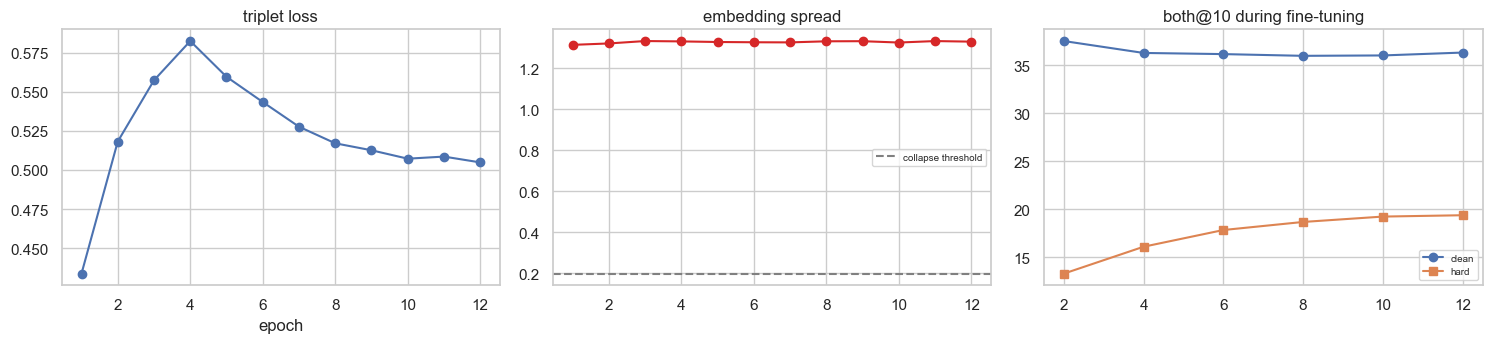

A flat triplet loss at the margin (0.30) with collapsing spread means the
model degenerated - lower bg_end or the learning rate if that happens.


In [13]:
# ============================================
# CELL 12 - Run the fine-tune
# ============================================

augmented_model, augmented_history = finetune_with_backgrounds()
display(augmented_history)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(augmented_history["epoch"], augmented_history["triplet"], marker="o")
axes[0].set_title("triplet loss"); axes[0].set_xlabel("epoch")
axes[1].plot(augmented_history["epoch"], augmented_history["spread"], marker="o",
             color="tab:red")
axes[1].axhline(0.15 * augmented_history["spread"].iloc[0], ls="--", color="grey",
                label="collapse threshold")
axes[1].set_title("embedding spread"); axes[1].legend(fontsize=7)
scored = augmented_history.dropna(subset=["clean_both"])
if len(scored):
    axes[2].plot(scored["epoch"], scored["clean_both"], marker="o", label="clean")
    axes[2].plot(scored["epoch"], scored["hard_both"], marker="s", label="hard")
    axes[2].set_title("both@10 during fine-tuning"); axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

print("A flat triplet loss at the margin (0.30) with collapsing spread means the")
print("model degenerated - lower bg_end or the learning rate if that happens.")

## 7. Full evaluation

The monitor above used a subset for speed. This runs both encoders over the **whole** catalogue
and the full query sets, which is the number to report.

In [14]:
# ============================================
# CELL 13 - Evaluate both encoders on both benchmarks
# ============================================

@torch.no_grad()
def embed_arrays(model, arrays, batch_size=256, tta=True):
    model.eval()
    out = []
    for start in range(0, len(arrays), batch_size):
        chunk = np.asarray(arrays[start:start + batch_size], dtype=np.float32) / 255.0
        tensor = torch.from_numpy(chunk.transpose(0, 3, 1, 2))
        tensor = ((tensor - MEAN_T) / STD_T).to(DEVICE)
        vectors = model.embed(tensor)
        if tta:
            vectors = F.normalize(vectors + model.embed(torch.flip(tensor, dims=[3])),
                                  p=2, dim=1)
        out.append(vectors.float().cpu().numpy())
    return np.vstack(out)


def evaluate(model, queries, label):
    catalogue = embed_arrays(model, np.asarray(IMAGES[CATALOGUE_POS]))
    catalogue /= np.clip(np.linalg.norm(catalogue, axis=1, keepdims=True), 1e-8, None)
    query_vectors = embed_arrays(model, queries)
    query_vectors /= np.clip(np.linalg.norm(query_vectors, axis=1, keepdims=True), 1e-8, None)

    similarity = torch.from_numpy(query_vectors).to(DEVICE) @ \
        torch.from_numpy(catalogue).to(DEVICE).T
    top = torch.topk(similarity, k=CONFIG["top_k"], dim=1).indices.cpu().numpy()
    positions = CATALOGUE_POS[top]

    type_hit = article[positions] == article[HELDOUT_QUERIES][:, None]
    colour_hit = colour_values[positions] == colour_values[HELDOUT_QUERIES][:, None]
    return {
        "model": label[0], "benchmark": label[1],
        "P@10": round(type_hit.mean() * 100, 2),
        "P@1": round(type_hit[:, 0].mean() * 100, 2),
        "colour@10": round(colour_hit.mean() * 100, 2),
        "both@10": round((type_hit & colour_hit).mean() * 100, 2),
    }


rows = []
for model, name in [(baseline_model, "baseline"), (augmented_model, "bg-augmented")]:
    for queries, benchmark in [(clean_queries, "clean"), (hard_queries, "hard")]:
        row = evaluate(model, queries, (name, benchmark))
        rows.append(row)
        print(f"{name:13s} {benchmark:6s} P@10 {row['P@10']:6.2f}  "
              f"colour@10 {row['colour@10']:6.2f}  both@10 {row['both@10']:6.2f}")

comparison = pd.DataFrame(rows)
display(comparison.pivot(index="model", columns="benchmark",
                         values=["P@10", "colour@10", "both@10"]))

baseline      clean  P@10  81.30  colour@10  56.22  both@10  45.84
baseline      hard   P@10   9.72  colour@10  24.66  both@10   3.28
bg-augmented  clean  P@10  79.68  colour@10  53.32  both@10  42.48
bg-augmented  hard   P@10  44.42  colour@10  41.59  both@10  21.66


P@10        colour@10        both@10       
benchmark     clean   hard     clean   hard   clean   hard
model                                                     
baseline      81.30   9.72     56.22  24.66   45.84   3.28
bg-augmented  79.68  44.42     53.32  41.59   42.48  21.66

,model,clean both@10,hard both@10,drop
0,baseline,45.84,3.28,42.56
1,bg-augmented,42.48,21.66,20.82



On realistic (hard) queries : +18.38 both@10
On clean catalogue queries  : -3.36 both@10

More robust out of domain, but it gave up in-domain accuracy.
Decide which distribution the product actually serves, and say so.


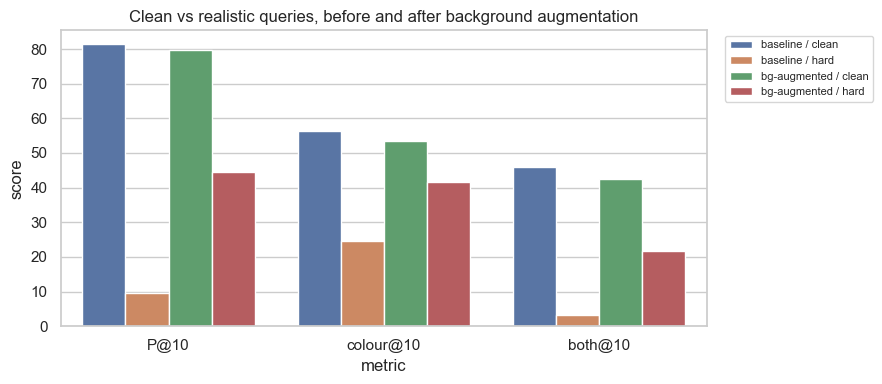

In [15]:
# ============================================
# CELL 14 - Did it work?
# ============================================

pivot = comparison.set_index(["model", "benchmark"])

def gap(model_name, metric):
    return round(pivot.loc[(model_name, "clean"), metric]
                 - pivot.loc[(model_name, "hard"), metric], 2)


robustness = pd.DataFrame([
    {"model": name,
     "clean both@10": pivot.loc[(name, "clean"), "both@10"],
     "hard both@10": pivot.loc[(name, "hard"), "both@10"],
     "drop": gap(name, "both@10")}
    for name in ["baseline", "bg-augmented"]
])
display(robustness)

improvement = (pivot.loc[("bg-augmented", "hard"), "both@10"]
               - pivot.loc[("baseline", "hard"), "both@10"])
cost = (pivot.loc[("bg-augmented", "clean"), "both@10"]
        - pivot.loc[("baseline", "clean"), "both@10"])

print(f"\nOn realistic (hard) queries : {improvement:+.2f} both@10")
print(f"On clean catalogue queries  : {cost:+.2f} both@10")
if improvement > 2 and cost > -2:
    print("\nMore robust out of domain at little or no in-domain cost - promote it.")
elif improvement > 2 and cost <= -2:
    print("\nMore robust out of domain, but it gave up in-domain accuracy.")
    print("Decide which distribution the product actually serves, and say so.")
elif cost < -10:
    print("\nThe in-domain drop is severe. Check the training curves: a triplet loss")
    print("stuck at the margin with a shrinking spread means the model collapsed and")
    print("the comparison is invalid, not a trade-off. Lower bg_end or the learning")
    print("rate and re-run before drawing any conclusion.")
else:
    print("\nNo meaningful gain. Report that honestly: augmentation was insufficient,")
    print("and the limit lies in resolution and the flat-lay-versus-worn domain gap.")

fig, ax = plt.subplots(figsize=(9, 4))
plot_data = comparison.melt(id_vars=["model", "benchmark"],
                            value_vars=["P@10", "colour@10", "both@10"],
                            var_name="metric", value_name="score")
sns.barplot(data=plot_data, x="metric", y="score", hue=plot_data["model"] + " / "
            + plot_data["benchmark"], ax=ax)
ax.set_title("Clean vs realistic queries, before and after background augmentation")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

comparison.to_csv(PROJECT_DIR / "outputs" / "background_augmentation_comparison.csv",
                  index=False)

## 8. Promote the new encoder (only if it earned it)

Artefacts are overwritten only when the augmented model is genuinely more robust. The previous
manifest is copied aside first, so the earlier results remain reproducible.

In [16]:
# ============================================
# CELL 15 - Save, if warranted
# ============================================

# The promotion rule has to state which distribution the product serves. This
# system takes photographs from users, so the `hard` benchmark is the target and
# `clean` is the academic reference. A fixed "cost > -3" gate ignored that and
# rejected a model that gained 18 points on the deployment distribution for a
# 3.4-point in-domain cost.
#
# Instead: promote when the out-of-domain gain outweighs the in-domain cost by a
# stated margin. DEPLOYMENT_WEIGHT is the preference, written down explicitly so
# the report can defend it rather than leaving it implicit in a magic number.
DEPLOYMENT_WEIGHT = 3.0        # 1 point of hard accuracy is worth 3 of clean
NOISE_FLOOR = 100 * np.sqrt(0.45 * 0.55 / len(HELDOUT_QUERIES))

weighted_gain = improvement + DEPLOYMENT_WEIGHT * cost
print(f"noise floor on both@10        : +-{NOISE_FLOOR:.2f} points")
print(f"hard gain                     : {improvement:+.2f}")
print(f"clean cost                    : {cost:+.2f}")
print(f"weighted gain (hard + {DEPLOYMENT_WEIGHT:g} x clean): {weighted_gain:+.2f}")

PROMOTE = weighted_gain > NOISE_FLOOR and improvement > NOISE_FLOOR
print("Decision:", "PROMOTE" if PROMOTE else "keep the existing model")

if PROMOTE:
    import shutil
    backup = ARTIFACT_DIR / "search_manifest_prev.json"
    shutil.copy(ARTIFACT_DIR / "search_manifest.json", backup)
    print("Previous manifest kept at", backup.name)

    catalogue = embed_arrays(augmented_model, np.asarray(IMAGES[CATALOGUE_POS]))
    catalogue /= np.clip(np.linalg.norm(catalogue, axis=1, keepdims=True), 1e-8, None)

    for old in ARTIFACT_DIR.glob("search_index_*.npy"):
        old.unlink()
    index_path = ARTIFACT_DIR / "search_index_bg_augmented.npy"
    np.save(index_path, catalogue.astype(np.float32))
    np.save(ARTIFACT_DIR / "gallery_ids.npy", gallery["id"].to_numpy()[CATALOGUE_POS])
    gallery.iloc[CATALOGUE_POS][
        ["id", "articleType", "subCategory", "masterCategory", "baseColour",
         "gender", "usage", "productDisplayName", "image_path"]
    ].to_csv(ARTIFACT_DIR / "gallery_metadata.csv", index=False)

    torch.save({
        "state_dict": augmented_model.state_dict(),
        "embedding_dim": CONFIG["embedding_dim"],
        "n_types": len(type_names), "n_colours": len(colour_names),
        "channel_mean": CHANNEL_MEAN.tolist(), "channel_std": CHANNEL_STD.tolist(),
        "image_size_pil": list(IMAGE_SIZE_PIL), "use_tta": True,
        "background_augmented": True,
    }, ARTIFACT_DIR / "task4_improved_encoder.pt")

    manifest = {
        "best_method": "Improved+TTA+bgaug",
        "index_file": index_path.name,
        "encoder_file": "task4_improved_encoder.pt",
        "catalogue_size": int(len(CATALOGUE_POS)),
        "embedding_dim": int(catalogue.shape[1]),
        "image_size_pil": list(IMAGE_SIZE_PIL),
        "channel_mean": CHANNEL_MEAN.tolist(), "channel_std": CHANNEL_STD.tolist(),
        "use_tta": True, "uses_reranking": False,
        "background_augmented": True,
        "deployment_metrics": {
            "P@10": pivot.loc[("bg-augmented", "clean"), "P@10"] / 100,
            "colour@10": pivot.loc[("bg-augmented", "clean"), "colour@10"] / 100,
            "both@10": pivot.loc[("bg-augmented", "clean"), "both@10"] / 100,
        },
        "hard_benchmark_metrics": {
            "P@10": pivot.loc[("bg-augmented", "hard"), "P@10"] / 100,
            "colour@10": pivot.loc[("bg-augmented", "hard"), "colour@10"] / 100,
            "both@10": pivot.loc[("bg-augmented", "hard"), "both@10"] / 100,
        },
    }
    with open(ARTIFACT_DIR / "search_manifest.json", "w") as handle:
        json.dump(manifest, handle, indent=2)

    print("Promoted. Re-run 07_user_image_search.ipynb to use the new encoder.")
else:
    print("Not promoted - the augmented model did not clear the bar.")
    print(f"  hard both@10 change {improvement:+.2f} (needs > +2)")
    print(f"  clean both@10 change {cost:+.2f} (needs > -3)")
    print("Existing artefacts are untouched.")

noise floor on both@10        : +-1.11 points
hard gain                     : +18.38
clean cost                    : -3.36
weighted gain (hard + 3 x clean): +8.30
Decision: PROMOTE
Previous manifest kept at search_manifest_prev.json
Promoted. Re-run 07_user_image_search.ipynb to use the new encoder.


### What to write up

* **Why augmentation was applied here but rejected in Task 3.** In Task 3 the test images were
  clean catalogue photographs, so augmentation only added noise. Here the deployment input is a
  user's photograph, so invariance to background and scale is exactly what is needed. Same
  technique, opposite conclusion, because the target distribution differs — a good illustration
  that augmentation is not universally good or bad.
* **The synthetic hard benchmark.** Real uploads carry no labels, so improvement cannot be
  measured on them. Compositing held-out items onto unseen backgrounds preserves ground truth
  while approximating the deployment distribution, and the gap between clean and hard is a
  direct measure of domain sensitivity.
* **Whatever the outcome.** If the gain is small, the honest conclusion is that 60x80 resolution
  and the flat-lay-versus-worn gap dominate, and the practical answer is to constrain the input
  (ask for a plain-background product photo) and reject low-confidence queries.